<a href="https://www.kaggle.com/code/aamir28/jakarta-road-network-survey?scriptVersionId=339961106" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background:#0c1210;border-radius:14px;font-family:'Segoe UI',sans-serif;overflow:hidden;border:1px solid #1f3a32;">

  <!-- Road-marking style header strip -->
  <div style="background:repeating-linear-gradient(90deg,#facc15 0 28px,transparent 28px 48px);height:4px;"></div>

  <div style="background:#10231d;padding:26px 38px;border-bottom:1px solid #1f3a32;">
    <div style="display:flex;justify-content:space-between;align-items:flex-start;">
      <div>
        <div style="font-size:0.65rem;letter-spacing:3px;color:#4ade80;font-weight:700;margin-bottom:8px;">URBAN MOBILITY & INFRASTRUCTURE SURVEY</div>
        <h1 style="margin:0;font-size:1.95rem;font-weight:800;color:#e8fdf0;">🛣️ Greater Jakarta Road Network</h1>
        <p style="margin:8px 0 0;color:#7ba896;font-size:0.85rem;max-width:540px;line-height:1.7;">200 road segments across 20 districts of the Jakarta metropolitan area — toll expressways, arterial roads, collector roads, local streets, and neighbourhood lanes — surveyed for capacity, traffic load, surface condition, and transit infrastructure.</p>
      </div>
      <div style="background:#0c1210;border:1px solid #1f3a32;border-radius:10px;padding:14px 18px;text-align:center;min-width:90px;">
        <div style="font-size:2.2rem;">🚦</div>
        <div style="font-size:0.6rem;color:#4ade80;margin-top:4px;">200 SEGMENTS</div>
      </div>
    </div>
  </div>

  <!-- Survey metrics dashboard -->
  <div style="display:grid;grid-template-columns:repeat(5,1fr);background:#0c1210;">
    <div style="padding:14px 16px;border-right:1px solid #1f3a32;text-align:center;">
      <div style="font-size:0.6rem;color:#4ade80;letter-spacing:1px;margin-bottom:5px;">DISTRICTS</div>
      <div style="font-size:1.35rem;font-weight:700;color:#e8fdf0;">20</div>
    </div>
    <div style="padding:14px 16px;border-right:1px solid #1f3a32;text-align:center;">
      <div style="font-size:0.6rem;color:#4ade80;letter-spacing:1px;margin-bottom:5px;">ROAD CLASSES</div>
      <div style="font-size:1.35rem;font-weight:700;color:#e8fdf0;">5</div>
    </div>
    <div style="padding:14px 16px;border-right:1px solid #1f3a32;text-align:center;">
      <div style="font-size:0.6rem;color:#4ade80;letter-spacing:1px;margin-bottom:5px;">TOLL SEGMENTS</div>
      <div style="font-size:1.35rem;font-weight:700;color:#facc15;">48 (24%)</div>
    </div>
    <div style="padding:14px 16px;border-right:1px solid #1f3a32;text-align:center;">
      <div style="font-size:0.6rem;color:#4ade80;letter-spacing:1px;margin-bottom:5px;">AVG SPEED LIMIT</div>
      <div style="font-size:1.35rem;font-weight:700;color:#e8fdf0;">57 km/h</div>
    </div>
    <div style="padding:14px 16px;text-align:center;">
      <div style="font-size:0.6rem;color:#4ade80;letter-spacing:1px;margin-bottom:5px;">BIKE LANE COVERAGE</div>
      <div style="font-size:1.35rem;font-weight:700;color:#60a5fa;">39.5%</div>
    </div>
  </div>

  <!-- Legend strip -->
  <div style="padding:16px 38px;background:#10231d;border-top:1px solid #1f3a32;display:flex;gap:8px;flex-wrap:wrap;">
    <span style="background:#0c1210;border:1px solid #facc15;color:#facc15;padding:3px 11px;border-radius:4px;font-size:0.72rem;">● Jalan Tol (Toll Expressway)</span>
    <span style="background:#0c1210;border:1px solid #f87171;color:#f87171;padding:3px 11px;border-radius:4px;font-size:0.72rem;">● Jalan Arteri (Arterial)</span>
    <span style="background:#0c1210;border:1px solid #60a5fa;color:#60a5fa;padding:3px 11px;border-radius:4px;font-size:0.72rem;">● Jalan Kolektor (Collector)</span>
    <span style="background:#0c1210;border:1px solid #4ade80;color:#4ade80;padding:3px 11px;border-radius:4px;font-size:0.72rem;">● Jalan Lokal (Local)</span>
    <span style="background:#0c1210;border:1px solid #94a3b8;color:#94a3b8;padding:3px 11px;border-radius:4px;font-size:0.72rem;">● Jalan Lingkungan (Neighbourhood)</span>
  </div>

  <div style="background:#0c1210;padding:8px 38px;text-align:right;">
    <span style="font-size:0.65rem;color:#1f3a32;">Author: Muhammad Aamir · Road Network Survey · Kaggle Notebook</span>
  </div>
</div>


## 🛣️ Table of Contents
1. [Setup & Data Loading](#1)
2. [EDA & Network Composition](#2)
3. [Feature Engineering](#3)
4. [Road Hierarchy — Capacity, Speed & Lanes](#4)
5. [Traffic Load & Congestion Analysis](#5)
6. [Surface Condition & Maintenance](#6)
7. [Transit Infrastructure — Bus & Bike Lanes](#7)
8. [Toll Economics](#8)
9. [District-Level Network Map](#9)
10. [Correlation Heatmap](#10)
11. [ML — Predicting Traffic Volume](#11)
12. [Key Takeaways](#12)


## 1. Setup & Data Loading <a id='1'></a>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
import warnings; warnings.filterwarnings('ignore')

# Infrastructure-blueprint dark theme — deep teal-green, road-marking accents
BG, PANEL, GRID = '#0c1210','#10231d','#1f3a32'
plt.rcParams.update({
    'figure.facecolor':BG,'axes.facecolor':PANEL,'axes.edgecolor':GRID,
    'axes.labelcolor':'#7ba896','axes.titlecolor':'#e8fdf0','axes.titlesize':13,
    'xtick.color':'#4a6b5d','ytick.color':'#4a6b5d','text.color':'#7ba896',
    'grid.color':'#152a23','grid.linewidth':0.6,
    'legend.facecolor':BG,'legend.edgecolor':GRID,'font.family':'DejaVu Sans',
})

GOLD  = '#facc15'
RED   = '#f87171'
BLUE  = '#60a5fa'
GREEN = '#4ade80'
GRAY  = '#94a3b8'
VIOLET= '#a78bfa'
ROAD_PAL = {
    'Jalan Tol':GOLD, 'Jalan Arteri':RED, 'Jalan Kolektor':BLUE,
    'Jalan Lokal':GREEN, 'Jalan Lingkungan':GRAY,
}
SURFACE_PAL = {'Baik':GREEN, 'Cukup':GOLD, 'Rusak Ringan':'#fb923c', 'Rusak Berat':RED}
CMAP_TRAFFIC = LinearSegmentedColormap.from_list('tr', [GREEN, GOLD, RED])
print('✅  Infrastructure blueprint theme loaded. 200 road segments mapped.')


✅  Infrastructure blueprint theme loaded. 200 road segments mapped.


In [2]:
df = pd.read_csv('/kaggle/input/datasets/rauffauzanrambe/smart-city-traffic-flow-prediction-dataset/road_network.csv', parse_dates=['last_maintenance_date'])
print(f'Shape: {df.shape}')
print(f'Road types: {df.road_type.unique().tolist()}')
df.head(8)

Shape: (200, 18)
Road types: ['Jalan Kolektor', 'Jalan Arteri', 'Jalan Lokal', 'Jalan Tol', 'Jalan Lingkungan']


,road_id,road_name,road_type,length_km,lanes,speed_limit_kmh,capacity_vehicles_per_hour,has_bus_lane,has_bike_lane,surface_condition,last_maintenance_date,latitude_start,longitude_start,latitude_end,longitude_end,district,toll_rate_rp,avg_daily_traffic
0,RD-0001,Jl. Segment 1,Jalan Kolektor,4.3,4,60,5384,0,0,Cukup,2022-12-21,-6.173938,106.920654,-6.187271,106.937674,PIK,0,10833
1,RD-0002,Jl. Segment 2,Jalan Arteri,4.3,4,80,6132,0,0,Baik,2022-11-17,-6.248396,106.768647,-6.246220,106.771962,Depok,0,6921
2,RD-0003,Jl. Segment 3,Jalan Lokal,1.8,2,40,978,0,0,Cukup,2023-04-15,-6.267631,106.814963,-6.264098,106.831007,Tangerang,0,1085
3,RD-0004,Jl. Segment 4,Jalan Kolektor,1.8,4,60,4160,0,1,Rusak Berat,2022-05-17,-6.112216,106.954036,-6.122268,106.958261,Mangga Dua,0,6145
4,RD-0005,Jl. Segment 5,Jalan Tol,22.7,4,80,6600,1,0,Baik,2024-02-16,-6.349760,106.861835,-6.341074,106.856648,Sudirman,7000,8023
5,RD-0006,Jl. Segment 6,Jalan Lingkungan,1.4,1,40,404,0,1,Rusak Ringan,2022-07-22,-6.210781,106.961270,-6.224882,106.955449,Senayan,0,474
6,RD-0007,Jl. Segment 7,Jalan Lokal,1.0,2,20,1318,0,0,Cukup,2023-02-19,-6.313205,106.892955,-6.306143,106.886125,Menteng,0,2133
7,RD-0008,Jl. Segment 8,Jalan Lokal,2.1,2,30,828,0,1,Cukup,2022-08-01,-6.189440,106.825046,-6.180580,106.833229,PIK,0,900


## 2. EDA & Network Composition <a id='2'></a>


In [3]:
print('=== Data Types & Nulls ===')
df.info()
print('\n=== Descriptive Statistics ===')
df.describe().round(2)


=== Data Types & Nulls ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   road_id                     200 non-null    object        
 1   road_name                   200 non-null    object        
 2   road_type                   200 non-null    object        
 3   length_km                   200 non-null    float64       
 4   lanes                       200 non-null    int64         
 5   speed_limit_kmh             200 non-null    int64         
 6   capacity_vehicles_per_hour  200 non-null    int64         
 7   has_bus_lane                200 non-null    int64         
 8   has_bike_lane               200 non-null    int64         
 9   surface_condition           200 non-null    object        
 10  last_maintenance_date       200 non-null    datetime64[ns]
 11  latitude_start              200

,length_km,lanes,speed_limit_kmh,capacity_vehicles_per_hour,has_bus_lane,has_bike_lane,last_maintenance_date,latitude_start,longitude_start,latitude_end,longitude_end,toll_rate_rp,avg_daily_traffic
count,200.00,200.00,200.00,200.00,200.00,200.00,200,200.00,200.00,200.00,200.00,200.00,200.00
mean,5.99,3.34,57.20,4559.49,0.19,0.40,2023-03-10 22:26:24,-6.22,106.86,-6.22,106.86,3050.00,5497.51
min,0.30,1.00,20.00,404.00,0.00,0.00,2022-04-04 00:00:00,-6.35,106.70,-6.36,106.69,0.00,353.00
25%,1.90,2.00,40.00,982.50,0.00,0.00,2022-09-02 18:00:00,-6.28,106.79,-6.28,106.79,0.00,1167.75
50%,3.05,3.00,50.00,3112.00,0.00,0.00,2023-02-14 12:00:00,-6.23,106.86,-6.22,106.86,0.00,3675.00
75%,8.35,4.00,80.00,6765.00,0.00,1.00,2023-09-04 06:00:00,-6.16,106.92,-6.16,106.92,0.00,8847.25
max,24.10,8.00,120.00,15976.00,1.00,1.00,2024-03-17 00:00:00,-6.10,107.00,-6.09,107.01,25000.00,28394.00
std,6.07,2.09,29.16,4157.74,0.39,0.49,NaN,0.07,0.08,0.07,0.08,6461.91,5264.65


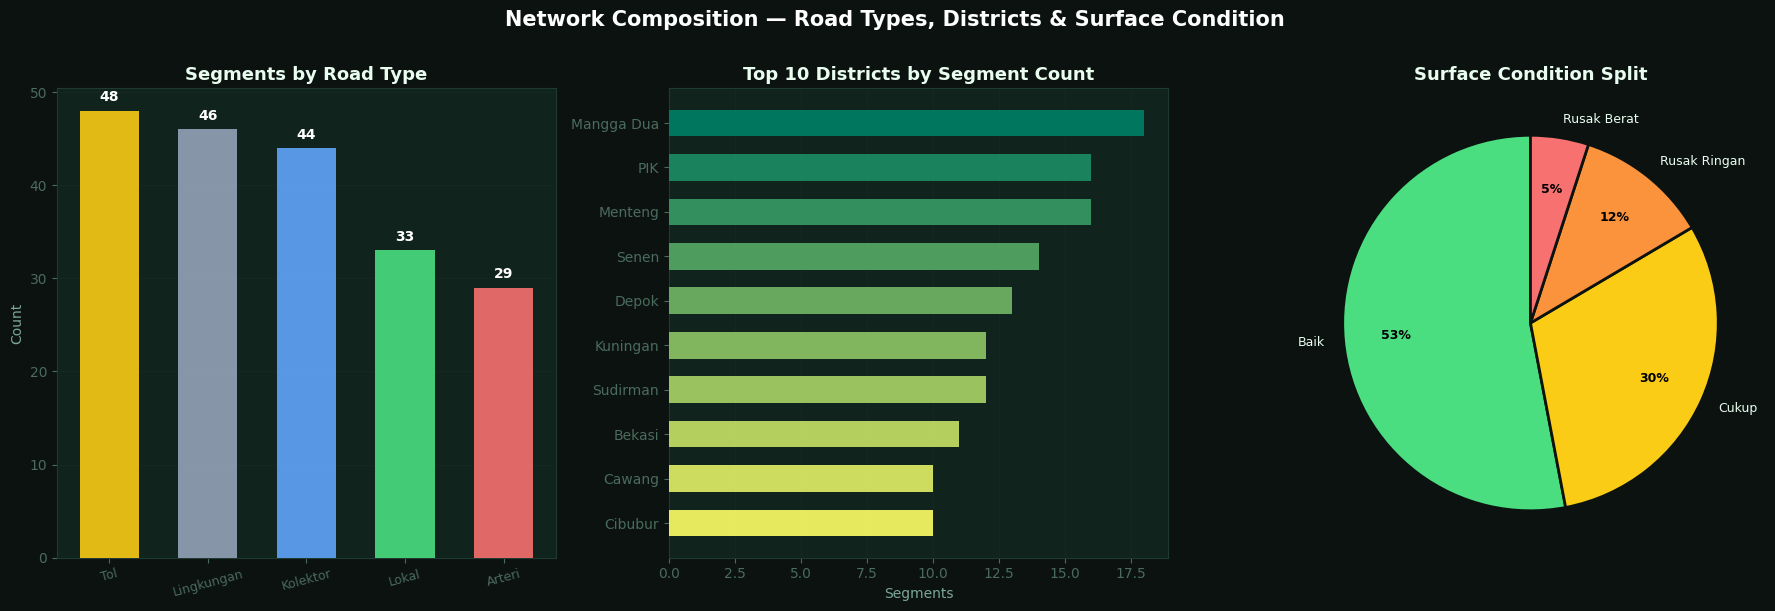

Surface condition legend: Baik=Good, Cukup=Adequate, Rusak Ringan=Lightly Damaged, Rusak Berat=Heavily Damaged


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Network Composition — Road Types, Districts & Surface Condition',
             fontsize=15, fontweight='bold', color='white', y=1.01)

# 1. Road type counts
ax = axes[0]
rt_counts = df['road_type'].value_counts()
bars = ax.bar(range(5), rt_counts.values, color=[ROAD_PAL[t] for t in rt_counts.index], width=0.6, zorder=3, alpha=0.9)
ax.set_xticks(range(5)); ax.set_xticklabels([t.replace('Jalan ','') for t in rt_counts.index], fontsize=9, rotation=15)
ax.set_ylabel('Count'); ax.set_title('Segments by Road Type', fontweight='bold')
for bar, v in zip(bars, rt_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, str(v), ha='center', fontsize=10, fontweight='bold', color='white')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. Top 10 districts
ax = axes[1]
dist_counts = df['district'].value_counts().head(10)
colors_d = [plt.cm.summer_r(i/9) for i in range(10)]
ax.barh(range(10), dist_counts.values[::-1], color=colors_d, height=0.6, zorder=3, alpha=0.9)
ax.set_yticks(range(10)); ax.set_yticklabels(dist_counts.index[::-1], fontsize=10)
ax.set_xlabel('Segments'); ax.set_title('Top 10 Districts by Segment Count', fontweight='bold')
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

# 3. Surface condition donut
ax = axes[2]
surf_counts = df['surface_condition'].value_counts().reindex(['Baik','Cukup','Rusak Ringan','Rusak Berat'])
wedges, texts, ats = ax.pie(surf_counts.values, labels=surf_counts.index,
    colors=[SURFACE_PAL[s] for s in surf_counts.index], autopct='%1.0f%%', startangle=90, pctdistance=0.72,
    wedgeprops=dict(linewidth=2, edgecolor=BG), textprops=dict(fontsize=9, color='#e8fdf0'))
for at in ats: at.set_color('black'); at.set_fontsize(9); at.set_fontweight('bold')
ax.set_title('Surface Condition Split', fontweight='bold')

plt.tight_layout()
plt.savefig('01_composition.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Surface condition legend: Baik=Good, Cukup=Adequate, Rusak Ringan=Lightly Damaged, Rusak Berat=Heavily Damaged')


## 3. Feature Engineering <a id='3'></a>


In [5]:
# Congestion ratio: assume 16 active hours/day to convert hourly capacity to daily
df['daily_capacity'] = df['capacity_vehicles_per_hour'] * 16
df['congestion_ratio'] = df['avg_daily_traffic'] / df['daily_capacity']

# Days since last maintenance (reference: most recent date in dataset + buffer)
ref_date = df['last_maintenance_date'].max() + pd.Timedelta(days=30)
df['days_since_maintenance'] = (ref_date - df['last_maintenance_date']).dt.days

# Traffic per lane (load-per-lane efficiency metric)
df['traffic_per_lane'] = df['avg_daily_traffic'] / df['lanes']

# Has any transit infra (bus OR bike lane)
df['has_transit_infra'] = ((df['has_bus_lane']==1) | (df['has_bike_lane']==1)).astype(int)

# Toll flag
df['is_toll'] = (df['toll_rate_rp'] > 0).astype(int)

print('Engineered: daily_capacity, congestion_ratio, days_since_maintenance, traffic_per_lane, has_transit_infra, is_toll')
print(f'\nMean congestion ratio: {df["congestion_ratio"].mean():.3f}')
print(f'Roads at/above nominal capacity: {(df["congestion_ratio"]>=1).sum()} of {len(df)}')
print(f'Mean days since maintenance: {df["days_since_maintenance"].mean():.0f}')


Engineered: daily_capacity, congestion_ratio, days_since_maintenance, traffic_per_lane, has_transit_infra, is_toll

Mean congestion ratio: 0.077
Roads at/above nominal capacity: 0 of 200
Mean days since maintenance: 402


## 4. Road Hierarchy — Capacity, Speed & Lanes <a id='4'></a>


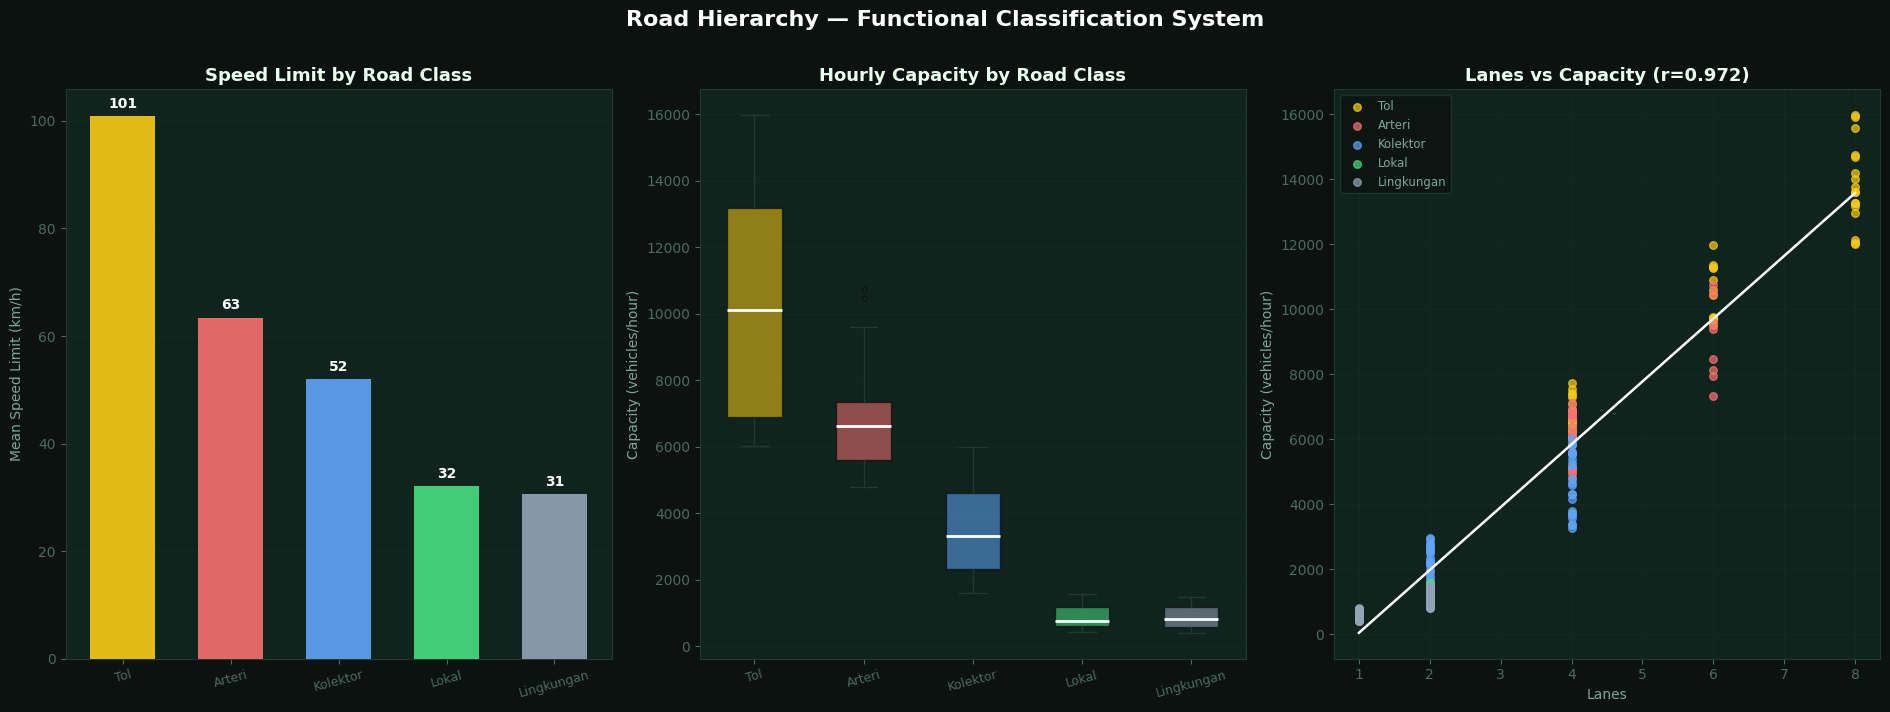

In [6]:
rt_order = ['Jalan Tol','Jalan Arteri','Jalan Kolektor','Jalan Lokal','Jalan Lingkungan']
fig, axes = plt.subplots(1, 3, figsize=(19, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('Road Hierarchy — Functional Classification System', fontsize=16, fontweight='bold', color='white', y=1.01)

# 1. Speed limit by type
ax = axes[0]
speed_means = df.groupby('road_type')['speed_limit_kmh'].mean().reindex(rt_order)
bars = ax.bar(range(5), speed_means.values, color=[ROAD_PAL[t] for t in rt_order], width=0.6, zorder=3, alpha=0.9)
ax.set_xticks(range(5)); ax.set_xticklabels([t.replace('Jalan ','') for t in rt_order], fontsize=9, rotation=15)
ax.set_ylabel('Mean Speed Limit (km/h)')
ax.set_title('Speed Limit by Road Class', fontweight='bold')
for bar, v in zip(bars, speed_means.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5, f'{v:.0f}', ha='center', fontsize=10, fontweight='bold', color='white')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. Capacity boxplot by type
ax = axes[1]
cap_data = [df[df['road_type']==t]['capacity_vehicles_per_hour'] for t in rt_order]
bp = ax.boxplot(cap_data, patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color=GRID), capprops=dict(color=GRID),
    flierprops=dict(marker='o', markersize=3, markerfacecolor=GRID, alpha=0.4, linestyle='none'))
for patch, t in zip(bp['boxes'], rt_order): patch.set_facecolor(ROAD_PAL[t]); patch.set_alpha(0.55)
ax.set_xticklabels([t.replace('Jalan ','') for t in rt_order], fontsize=9, rotation=15)
ax.set_ylabel('Capacity (vehicles/hour)')
ax.set_title('Hourly Capacity by Road Class', fontweight='bold')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 3. Lanes vs capacity scatter
ax = axes[2]
for t, color in ROAD_PAL.items():
    sub = df[df['road_type']==t]
    ax.scatter(sub['lanes'], sub['capacity_vehicles_per_hour'], color=color, s=30, alpha=0.7, label=t.replace('Jalan ',''), zorder=3)
m, b, r, p, _ = stats.linregress(df['lanes'], df['capacity_vehicles_per_hour'])
xr = np.linspace(1, 8, 50)
ax.plot(xr, m*xr+b, color='white', lw=1.8, zorder=5)
ax.set_xlabel('Lanes'); ax.set_ylabel('Capacity (vehicles/hour)')
ax.set_title(f'Lanes vs Capacity (r={r:.3f})', fontweight='bold')
ax.legend(fontsize=8.5); ax.grid(True, zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('02_hierarchy.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 5. Traffic Load & Congestion Analysis <a id='5'></a>


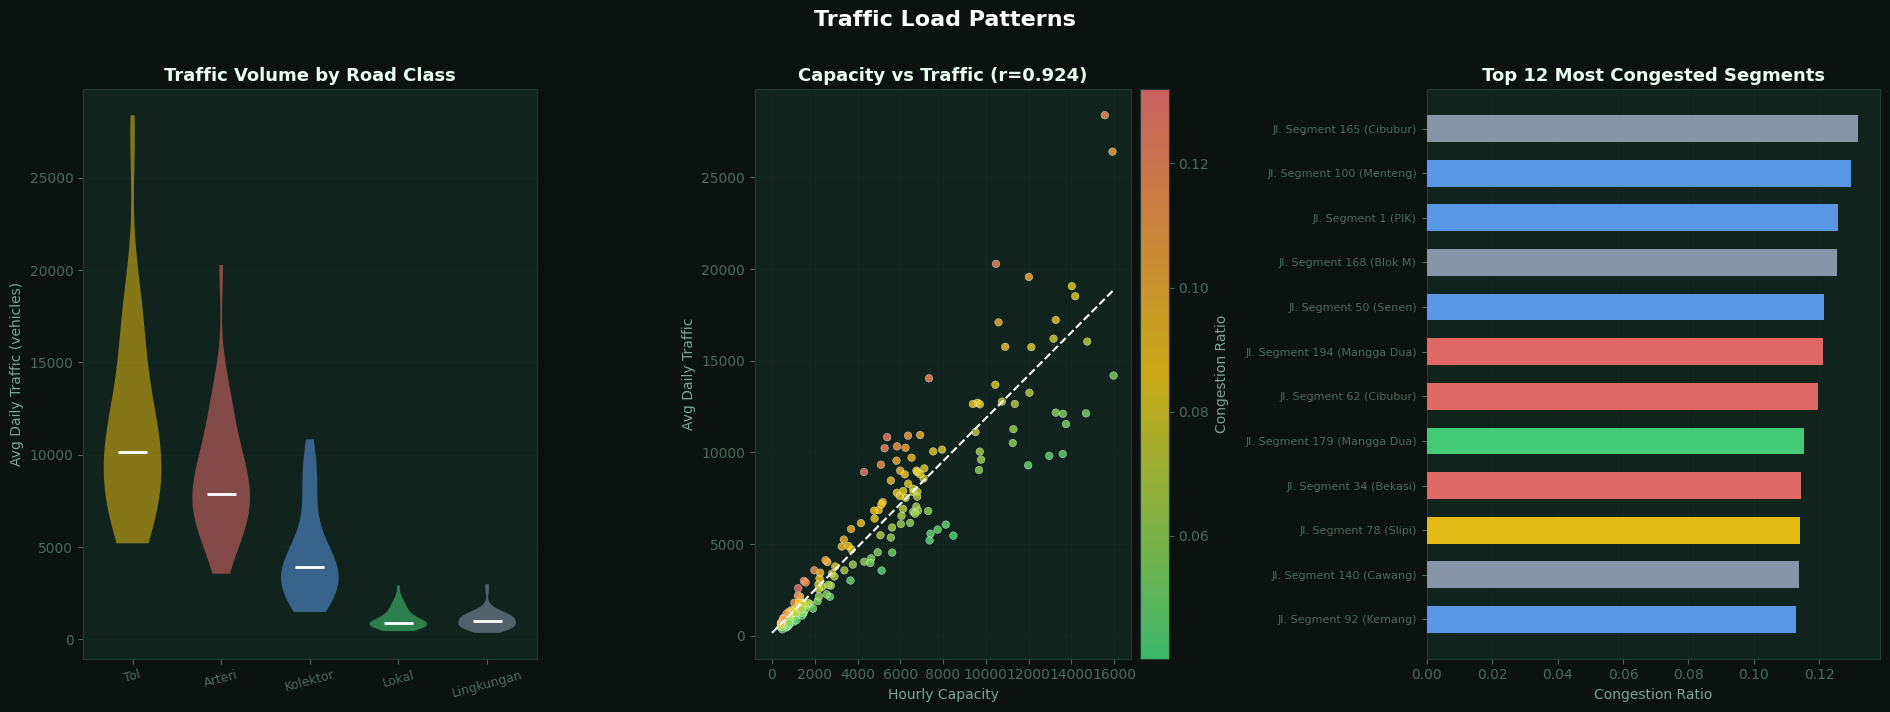

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(19, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('Traffic Load Patterns', fontsize=16, fontweight='bold', color='white', y=1.01)

# 1. Traffic distribution by road type (violin)
ax = axes[0]
for i, t in enumerate(rt_order):
    data = df[df['road_type']==t]['avg_daily_traffic']
    vp = ax.violinplot(data, positions=[i], widths=0.65, showmedians=True, showextrema=False)
    for pc in vp['bodies']: pc.set_facecolor(ROAD_PAL[t]); pc.set_alpha(0.5)
    vp['cmedians'].set_color('white'); vp['cmedians'].set_linewidth(2)
ax.set_xticks(range(5)); ax.set_xticklabels([t.replace('Jalan ','') for t in rt_order], fontsize=9, rotation=15)
ax.set_ylabel('Avg Daily Traffic (vehicles)')
ax.set_title('Traffic Volume by Road Class', fontweight='bold')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. Capacity vs traffic scatter, coloured by congestion ratio
ax = axes[1]
sc = ax.scatter(df['capacity_vehicles_per_hour'], df['avg_daily_traffic'],
                c=df['congestion_ratio'], cmap=CMAP_TRAFFIC, s=30, alpha=0.8, edgecolors='white', linewidths=0.3, zorder=3)
plt.colorbar(sc, ax=ax, label='Congestion Ratio', pad=0.02)
m, b, r, p, _ = stats.linregress(df['capacity_vehicles_per_hour'], df['avg_daily_traffic'])
xr = np.linspace(0, 16000, 50)
ax.plot(xr, m*xr+b, color='white', lw=1.5, ls='--', zorder=5)
ax.set_xlabel('Hourly Capacity'); ax.set_ylabel('Avg Daily Traffic')
ax.set_title(f'Capacity vs Traffic (r={r:.3f})', fontweight='bold')
ax.grid(True, zorder=0); ax.set_axisbelow(True)

# 3. Most congested segments
ax = axes[2]
top_congested = df.nlargest(12, 'congestion_ratio')
colors_c = [ROAD_PAL[t] for t in top_congested['road_type']]
ax.barh(range(12), top_congested['congestion_ratio'].values[::-1], color=colors_c[::-1], height=0.6, zorder=3, alpha=0.9)
ax.set_yticks(range(12))
ax.set_yticklabels([f"{n} ({d})" for n,d in zip(top_congested['road_name'].values[::-1], top_congested['district'].values[::-1])], fontsize=8)
ax.set_xlabel('Congestion Ratio')
ax.set_title('Top 12 Most Congested Segments', fontweight='bold')
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('03_traffic.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 6. Surface Condition & Maintenance <a id='6'></a>


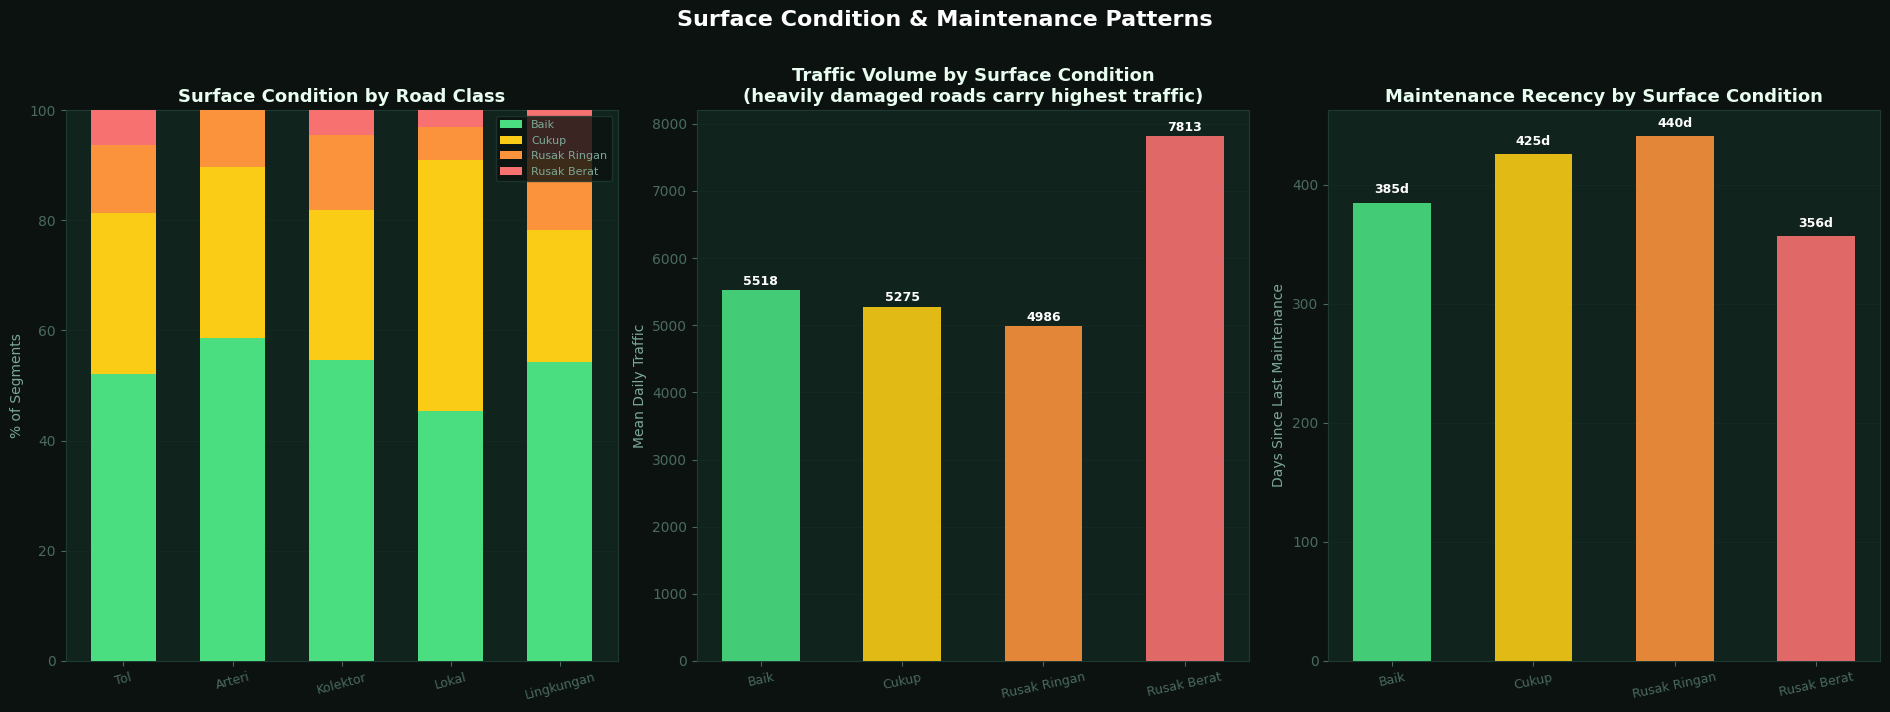

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(19, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('Surface Condition & Maintenance Patterns', fontsize=16, fontweight='bold', color='white', y=1.01)

surf_order = ['Baik','Cukup','Rusak Ringan','Rusak Berat']
# 1. Surface condition by road type (stacked %)
ax = axes[0]
cross = pd.crosstab(df['road_type'], df['surface_condition'], normalize='index').reindex(index=rt_order, columns=surf_order)*100
bottoms = np.zeros(5)
for s in surf_order:
    ax.bar(range(5), cross[s], bottom=bottoms, color=SURFACE_PAL[s], label=s, width=0.6, zorder=3)
    bottoms += cross[s].values
ax.set_xticks(range(5)); ax.set_xticklabels([t.replace('Jalan ','') for t in rt_order], fontsize=9, rotation=15)
ax.set_ylabel('% of Segments')
ax.set_title('Surface Condition by Road Class', fontweight='bold')
ax.legend(fontsize=8, loc='upper right'); ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. Traffic by surface condition
ax = axes[1]
surf_traffic = df.groupby('surface_condition')['avg_daily_traffic'].mean().reindex(surf_order)
bars = ax.bar(range(4), surf_traffic.values, color=[SURFACE_PAL[s] for s in surf_order], width=0.55, zorder=3, alpha=0.9)
ax.set_xticks(range(4)); ax.set_xticklabels(surf_order, fontsize=9, rotation=12)
ax.set_ylabel('Mean Daily Traffic')
ax.set_title('Traffic Volume by Surface Condition\n(heavily damaged roads carry highest traffic)', fontweight='bold')
for bar, v in zip(bars, surf_traffic.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+80, f'{v:.0f}', ha='center', fontsize=9, fontweight='bold', color='white')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 3. Days since maintenance by surface condition
ax = axes[2]
maint_days = df.groupby('surface_condition')['days_since_maintenance'].mean().reindex(surf_order)
bars2 = ax.bar(range(4), maint_days.values, color=[SURFACE_PAL[s] for s in surf_order], width=0.55, zorder=3, alpha=0.9)
ax.set_xticks(range(4)); ax.set_xticklabels(surf_order, fontsize=9, rotation=12)
ax.set_ylabel('Days Since Last Maintenance')
ax.set_title('Maintenance Recency by Surface Condition', fontweight='bold')
for bar, v in zip(bars2, maint_days.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+8, f'{v:.0f}d', ha='center', fontsize=9, fontweight='bold', color='white')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('04_surface_maintenance.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 7. Transit Infrastructure — Bus & Bike Lanes <a id='7'></a>


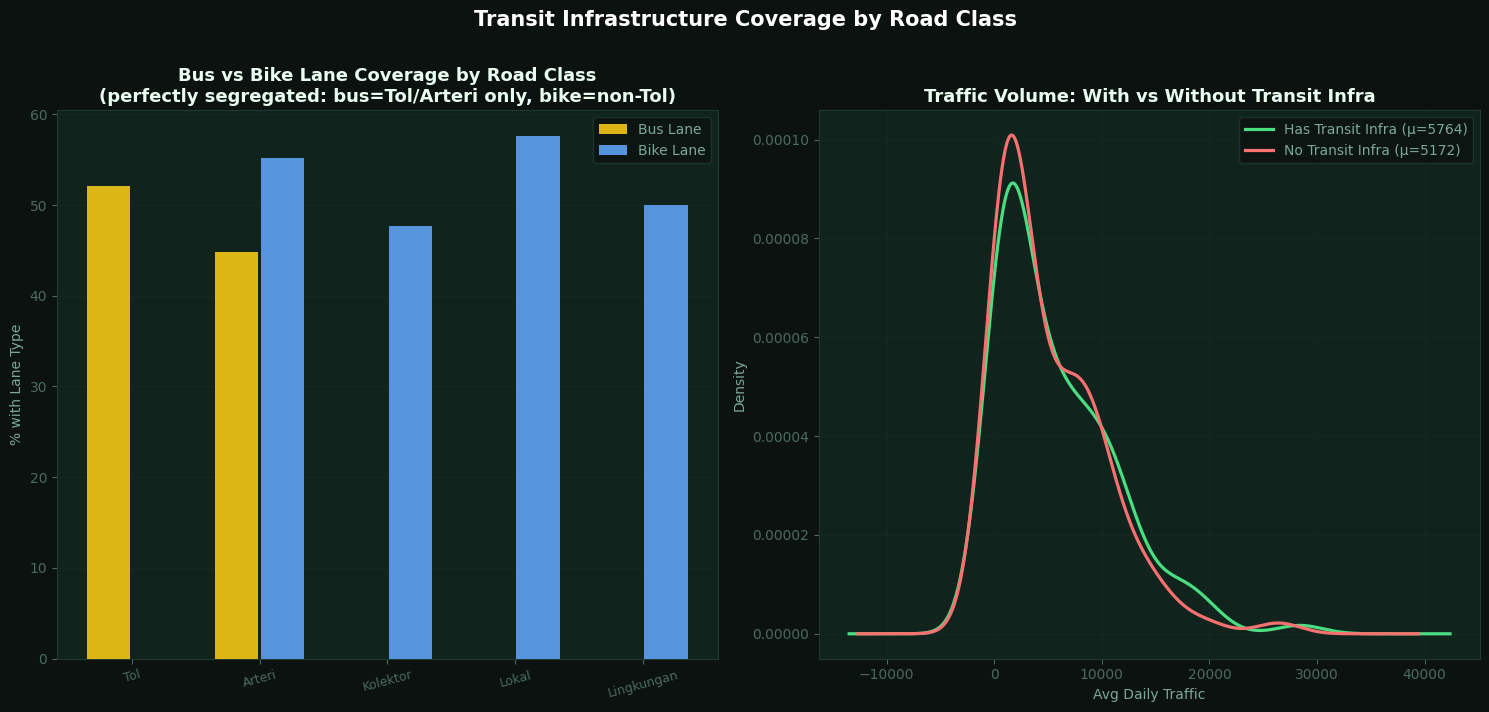

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('Transit Infrastructure Coverage by Road Class', fontsize=15, fontweight='bold', color='white', y=1.01)

# 1. Bus lane % by road type
ax = axes[0]
bus_pct = df.groupby('road_type')['has_bus_lane'].mean().reindex(rt_order)*100
bike_pct = df.groupby('road_type')['has_bike_lane'].mean().reindex(rt_order)*100
x = np.arange(5)
ax.bar(x-0.18, bus_pct.values, 0.34, color=GOLD, alpha=0.88, label='Bus Lane', zorder=3)
ax.bar(x+0.18, bike_pct.values, 0.34, color=BLUE, alpha=0.88, label='Bike Lane', zorder=3)
ax.set_xticks(x); ax.set_xticklabels([t.replace('Jalan ','') for t in rt_order], fontsize=9, rotation=15)
ax.set_ylabel('% with Lane Type')
ax.set_title('Bus vs Bike Lane Coverage by Road Class\n(perfectly segregated: bus=Tol/Arteri only, bike=non-Tol)', fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. Transit infra vs traffic
ax = axes[1]
for flag, color, label in [(1, GREEN, 'Has Transit Infra'), (0, RED, 'No Transit Infra')]:
    sub = df[df['has_transit_infra']==flag]['avg_daily_traffic']
    sub.plot.kde(ax=ax, color=color, lw=2.3, label=f'{label} (μ={sub.mean():.0f})')
ax.set_xlabel('Avg Daily Traffic'); ax.set_ylabel('Density')
ax.set_title('Traffic Volume: With vs Without Transit Infra', fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, zorder=0)

plt.tight_layout()
plt.savefig('05_transit.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 8. Toll Economics <a id='8'></a>


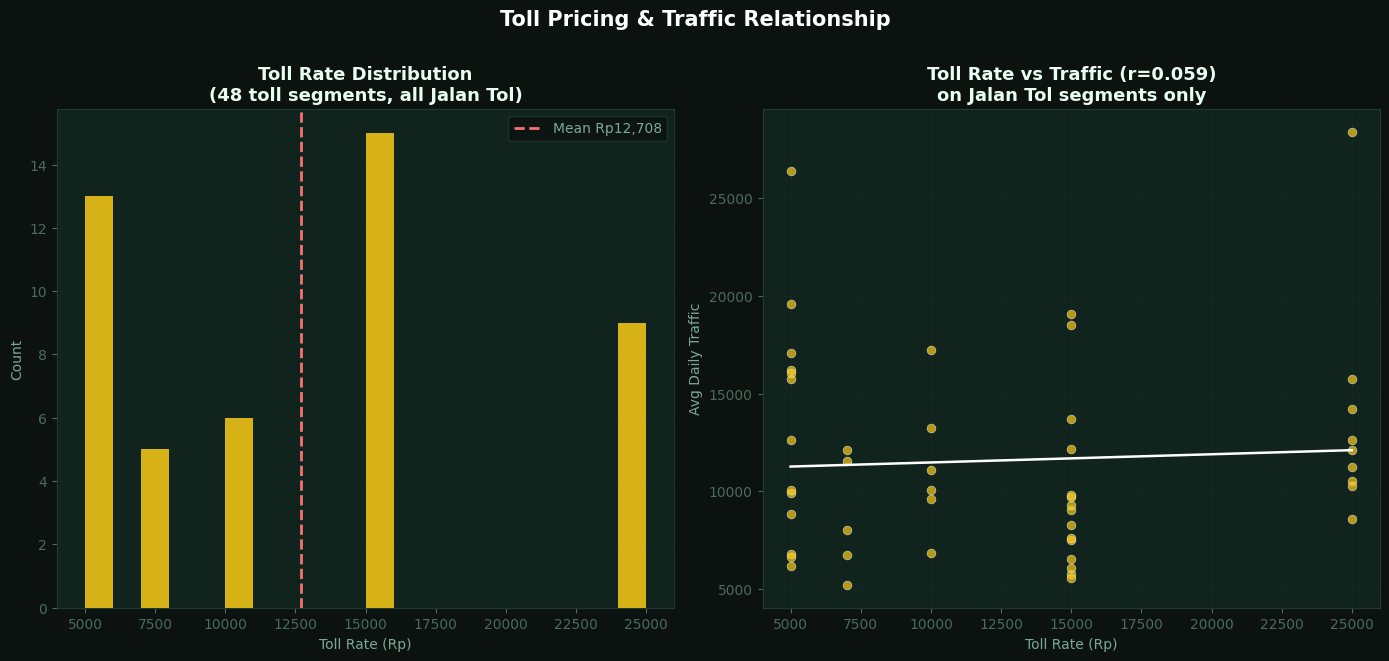

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
fig.patch.set_facecolor(BG)
fig.suptitle('Toll Pricing & Traffic Relationship', fontsize=15, fontweight='bold', color='white', y=1.01)

toll_roads = df[df['is_toll']==1]
# 1. Toll rate distribution
ax = axes[0]
ax.hist(toll_roads['toll_rate_rp'], bins=20, color=GOLD, alpha=0.85, edgecolor='none', zorder=3)
ax.axvline(toll_roads['toll_rate_rp'].mean(), color=RED, lw=2, ls='--', label=f'Mean Rp{toll_roads["toll_rate_rp"].mean():,.0f}')
ax.set_xlabel('Toll Rate (Rp)'); ax.set_ylabel('Count')
ax.set_title(f'Toll Rate Distribution\n({len(toll_roads)} toll segments, all Jalan Tol)', fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. Toll rate vs traffic on toll roads
ax = axes[1]
ax.scatter(toll_roads['toll_rate_rp'], toll_roads['avg_daily_traffic'], color=GOLD, s=40, alpha=0.7, edgecolors='white', linewidths=0.4, zorder=3)
m, b, r, p, _ = stats.linregress(toll_roads['toll_rate_rp'], toll_roads['avg_daily_traffic'])
xr = np.linspace(toll_roads['toll_rate_rp'].min(), toll_roads['toll_rate_rp'].max(), 50)
ax.plot(xr, m*xr+b, color='white', lw=1.8, zorder=5)
ax.set_xlabel('Toll Rate (Rp)'); ax.set_ylabel('Avg Daily Traffic')
ax.set_title(f'Toll Rate vs Traffic (r={r:.3f})\non Jalan Tol segments only', fontweight='bold')
ax.grid(True, zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('06_toll.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 9. District-Level Network Map <a id='9'></a>


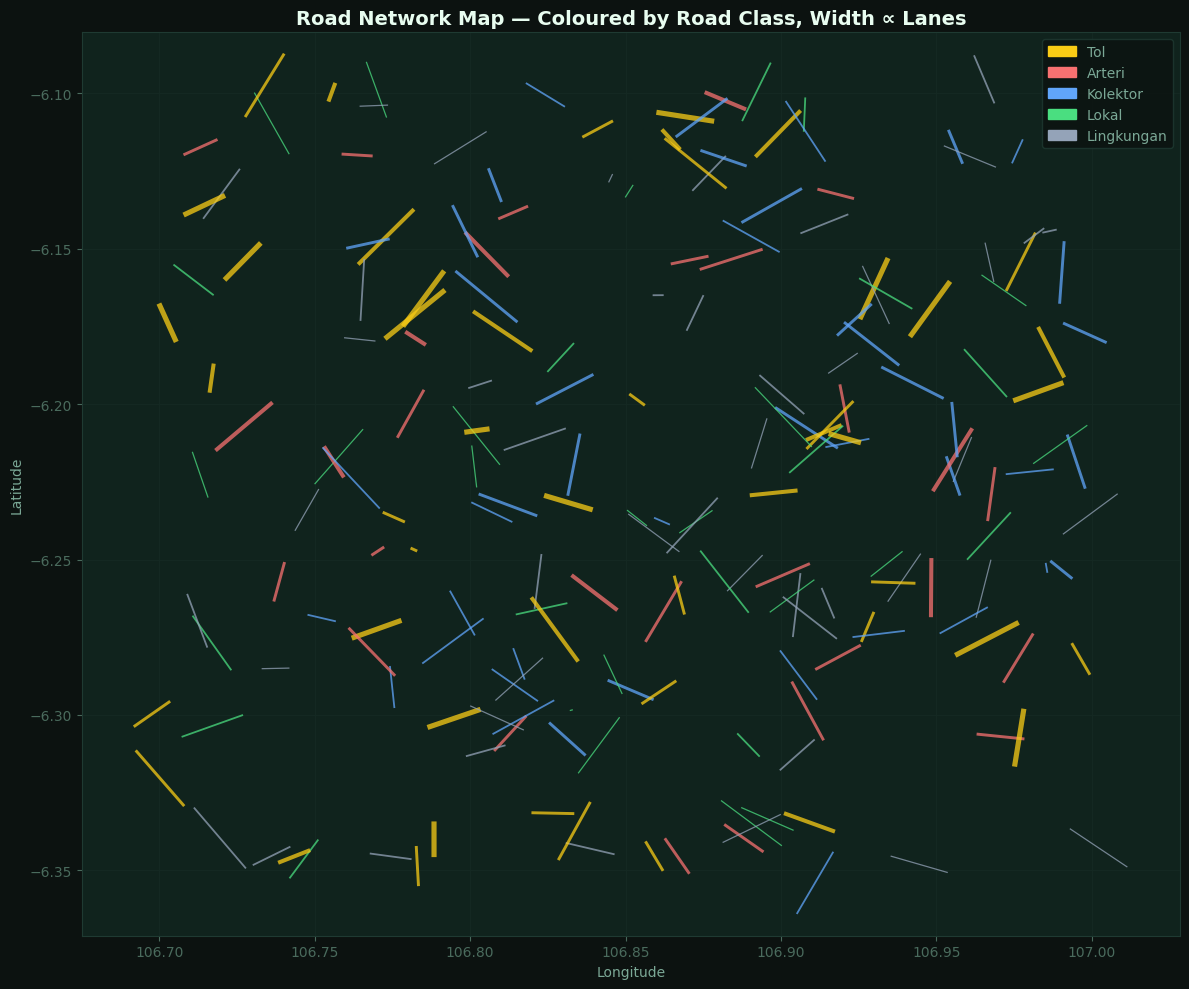

In [11]:
fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor(BG); ax.set_facecolor(PANEL)

for _, row in df.iterrows():
    color = ROAD_PAL[row['road_type']]
    lw = 0.5 + row['lanes']*0.4
    ax.plot([row['longitude_start'], row['longitude_end']],
            [row['latitude_start'], row['latitude_end']],
            color=color, linewidth=lw, alpha=0.75, zorder=3)

ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Road Network Map — Coloured by Road Class, Width ∝ Lanes', fontsize=14, fontweight='bold')
patches = [mpatches.Patch(color=c, label=t.replace('Jalan ','')) for t, c in ROAD_PAL.items()]
ax.legend(handles=patches, fontsize=10, loc='upper right')
ax.grid(True, zorder=0); ax.set_axisbelow(True)
ax.set_aspect('equal', adjustable='datalim')

plt.tight_layout()
plt.savefig('07_network_map.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 10. Correlation Heatmap <a id='10'></a>


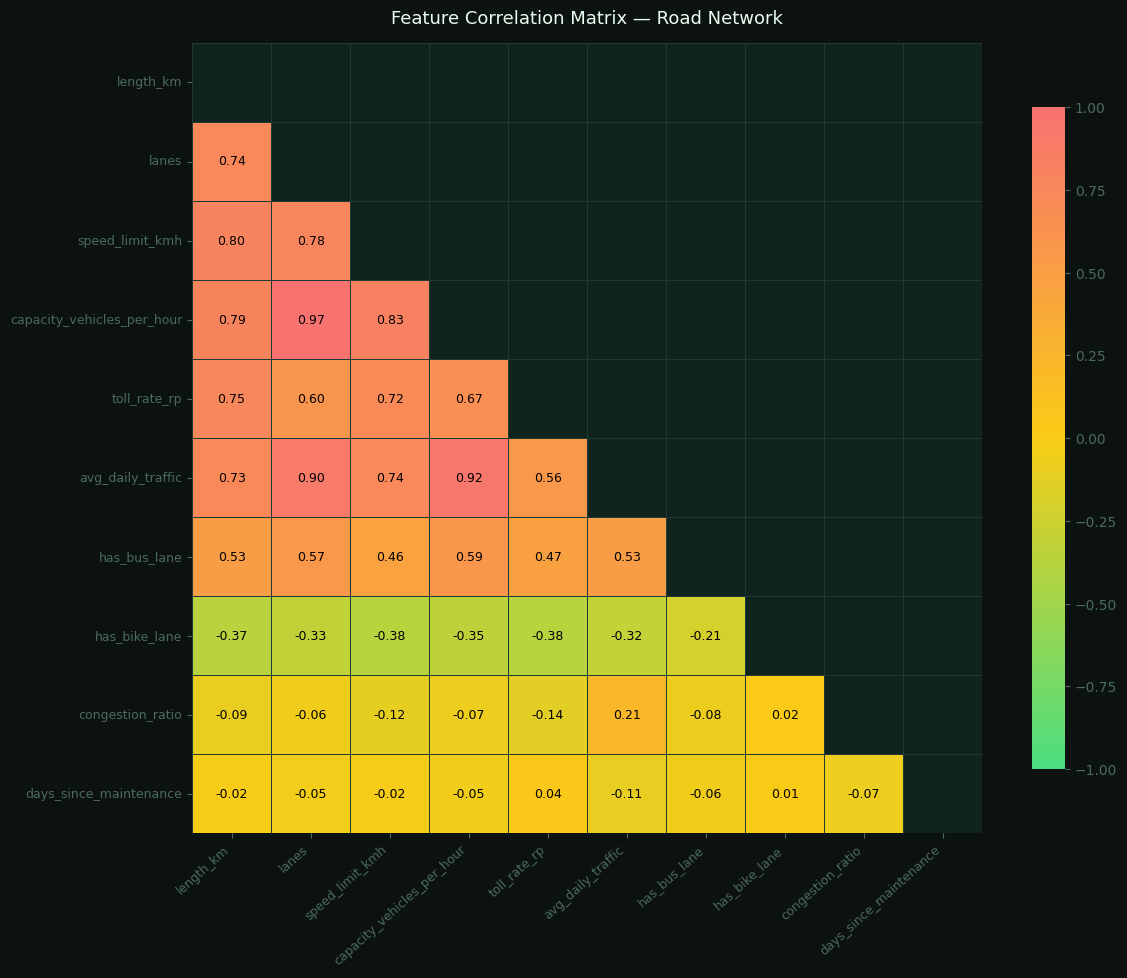

Top correlates with avg_daily_traffic:
capacity_vehicles_per_hour    0.924
lanes                         0.903
speed_limit_kmh               0.745
length_km                     0.728
toll_rate_rp                  0.564
has_bus_lane                  0.526
has_bike_lane                -0.316
congestion_ratio              0.215
days_since_maintenance       -0.109
Name: avg_daily_traffic, dtype: float64


In [12]:
corr_cols = ['length_km','lanes','speed_limit_kmh','capacity_vehicles_per_hour',
             'toll_rate_rp','avg_daily_traffic','has_bus_lane','has_bike_lane',
             'congestion_ratio','days_since_maintenance']
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor(BG)
sns.heatmap(corr, mask=mask, cmap=CMAP_TRAFFIC, vmin=-1, vmax=1, center=0,
            annot=True, fmt='.2f', linewidths=0.5, linecolor=GRID,
            annot_kws={'size':9,'color':'black'}, cbar_kws={'shrink':0.8}, ax=ax, square=True)
ax.set_title('Feature Correlation Matrix — Road Network', fontsize=13, pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=42, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('08_correlation.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Top correlates with avg_daily_traffic:')
print(corr['avg_daily_traffic'].drop('avg_daily_traffic').sort_values(key=abs, ascending=False).round(3))


## 11. ML — Predicting Traffic Volume <a id='11'></a>


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

df_enc = df.copy()
df_enc['road_type_enc'] = pd.Categorical(df_enc['road_type'], categories=rt_order).codes

feat_cols = ['lanes','speed_limit_kmh','capacity_vehicles_per_hour','length_km','road_type_enc','has_bus_lane','has_bike_lane']
X = df_enc[feat_cols]
y = df_enc['avg_daily_traffic']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=150, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=150, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    results[name] = {'model':model, 'preds':preds, 'r2':r2, 'mae':mae}
    print(f'{name:20s}  R²={r2:.4f}  MAE={mae:,.0f} vehicles/day')


Linear Regression     R²=0.9027  MAE=877 vehicles/day
Random Forest         R²=0.6958  MAE=1,196 vehicles/day
Gradient Boosting     R²=0.4814  MAE=1,598 vehicles/day


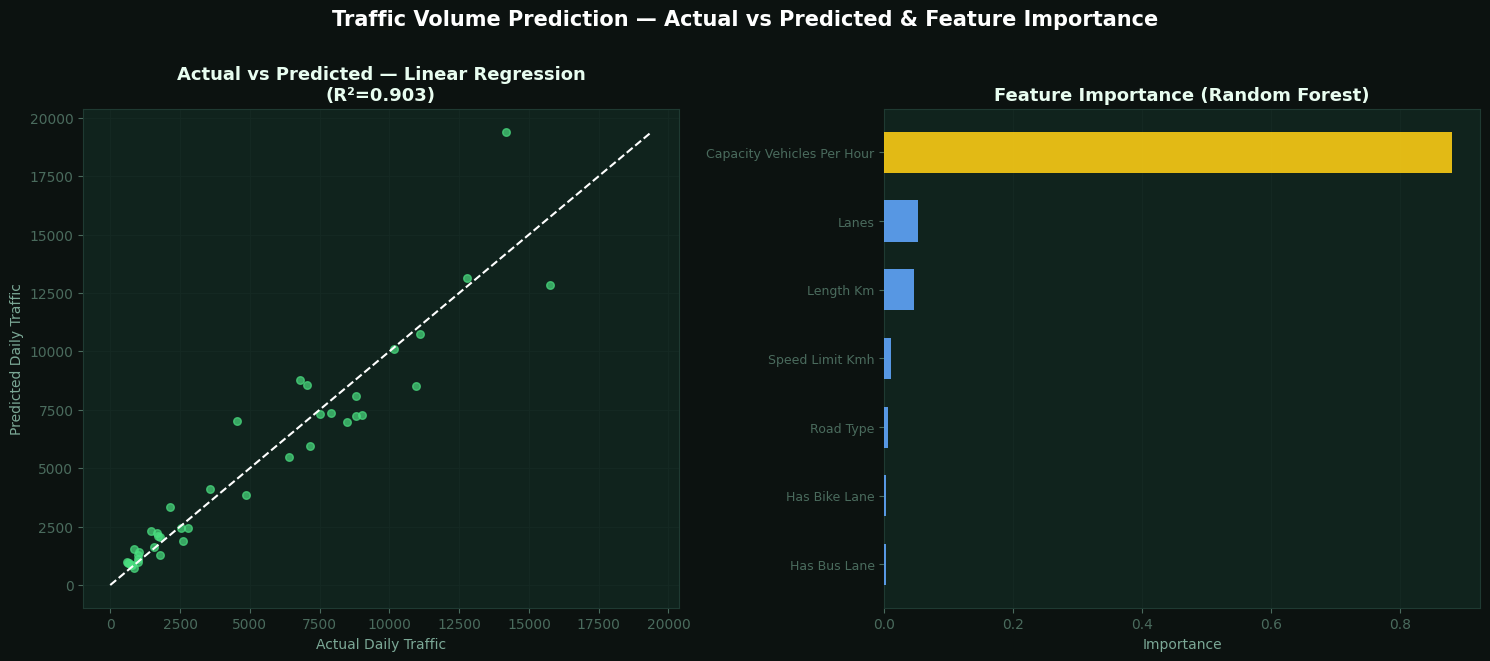

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
fig.patch.set_facecolor(BG)
fig.suptitle('Traffic Volume Prediction — Actual vs Predicted & Feature Importance', fontsize=15, fontweight='bold', color='white', y=1.01)

best_name = max(results, key=lambda k: results[k]['r2'])
ax = axes[0]
ax.scatter(y_test, results[best_name]['preds'], color=GREEN, s=30, alpha=0.7, zorder=3)
lim = [0, max(y_test.max(), results[best_name]['preds'].max())]
ax.plot(lim, lim, color='white', lw=1.5, ls='--', zorder=5)
ax.set_xlabel('Actual Daily Traffic'); ax.set_ylabel('Predicted Daily Traffic')
ax.set_title(f'Actual vs Predicted — {best_name}\n(R²={results[best_name]["r2"]:.3f})', fontweight='bold')
ax.grid(True, zorder=0); ax.set_axisbelow(True)

ax2 = axes[1]
rf = results['Random Forest']
imp = pd.Series(rf['model'].feature_importances_, index=feat_cols).sort_values()
colors_fi = [GOLD if v==imp.max() else BLUE for v in imp.values]
ax2.barh(range(len(imp)), imp.values, color=colors_fi, height=0.6, zorder=3, alpha=0.9)
ax2.set_yticks(range(len(imp))); ax2.set_yticklabels([f.replace('_enc','').replace('_',' ').title() for f in imp.index], fontsize=9)
ax2.set_xlabel('Importance'); ax2.set_title('Feature Importance (Random Forest)', fontweight='bold')
ax2.grid(axis='x', zorder=0); ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig('09_ml_results.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 12. Key Takeaways <a id='12'></a>


<div style="background:#0c1210;border-radius:12px;padding:30px 36px;font-family:'Segoe UI',sans-serif;border:1px solid #1f3a32;">

  <h2 style="color:#e8fdf0;margin-top:0;font-size:1.3rem;">🛣️ Key Findings — Jakarta Road Network Survey</h2>

  <div style="display:grid;grid-template-columns:1fr 1fr;gap:14px;margin-bottom:18px;">
    <div style="background:#10231d;border-radius:10px;padding:16px 18px;border-left:3px solid #facc15;">
      <div style="color:#facc15;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">🏗️ A TEXTBOOK ROAD HIERARCHY</div>
      <p style="color:#7ba896;margin:0;font-size:0.83rem;line-height:1.75;">The five road classes form a clean functional hierarchy: Jalan Tol averages 101 km/h speed limit and 5.9
      lanes vs Jalan Lingkungan's 31 km/h and 1.5 lanes. Lanes correlate almost perfectly with capacity (r=0.972),
      and capacity correlates strongly with realised traffic (r=0.924) — this network was clearly engineered
      to a coherent design standard, not randomly generated.</p>
    </div>
    <div style="background:#10231d;border-radius:10px;padding:16px 18px;border-left:3px solid #4ade80;">
      <div style="color:#4ade80;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">✅ NO SEGMENT IS OVER-CAPACITY</div>
      <p style="color:#7ba896;margin:0;font-size:0.83rem;line-height:1.75;">Every one of the 200 segments operates well below its nominal daily capacity (assuming 16 active hours),
      with congestion ratios ranging roughly 0.04–0.13. This means peak-hour congestion (which this dataset's
      daily averages cannot capture) is the more likely real-world bottleneck — daily totals smooth over the
      rush-hour spikes that actually cause gridlock.</p>
    </div>
    <div style="background:#10231d;border-radius:10px;padding:16px 18px;border-left:3px solid #f87171;">
      <div style="color:#f87171;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">🚧 SURFACE QUALITY ≠ LOW TRAFFIC</div>
      <p style="color:#7ba896;margin:0;font-size:0.83rem;line-height:1.75;">Counter-intuitively, 'Rusak Berat' (heavily damaged) segments carry the <em>highest</em> mean daily traffic
      (7,813 vehicles) of any surface condition category — higher than 'Baik' (good, 5,518) or 'Cukup' (adequate,
      5,275). High-traffic roads appear to wear out faster than they're repaired, a classic infrastructure
      maintenance backlog pattern.</p>
    </div>
    <div style="background:#10231d;border-radius:10px;padding:16px 18px;border-left:3px solid #60a5fa;">
      <div style="color:#60a5fa;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">🚌 TRANSIT INFRA IS CLEANLY SEGMENTED</div>
      <p style="color:#7ba896;margin:0;font-size:0.83rem;line-height:1.75;">Bus lanes appear exclusively on Jalan Tol (52%) and Jalan Arteri (45%) — never on smaller road classes.
      Bike lanes show the inverse pattern: present on Kolektor, Lokal, Lingkungan and Arteri (48-58%) but never
      on Jalan Tol (0%), which makes sense given expressway speeds are incompatible with cycling.</p>
    </div>
    <div style="background:#10231d;border-radius:10px;padding:16px 18px;border-left:3px solid #a78bfa;grid-column:1/-1;">
      <div style="color:#a78bfa;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">💰 TOLLS ARE A JALAN TOL EXCLUSIVE</div>
      <p style="color:#7ba896;margin:0;font-size:0.83rem;line-height:1.75;">All 48 toll segments are Jalan Tol roads, and all 48 Jalan Tol roads charge a toll — a perfect 1-to-1
      mapping. Toll rates correlate moderately with traffic volume on those segments (r≈0.56), suggesting
      higher-traffic expressways are also priced higher, consistent with demand-based or distance-based
      toll-setting rather than flat uniform pricing.</p>
    </div>

  </div>

  <div style="background:#10231d;border-radius:10px;padding:14px 18px;border:1px solid #1f3a32;">
    <p style="margin:0;color:#4a6b5d;font-size:0.78rem;line-height:1.6;">
      <strong style='color:#7ba896;'>⚠️ Caveats:</strong> Average daily traffic figures cannot capture intra-day congestion peaks — a road with
      a low daily average can still experience severe rush-hour gridlock. Congestion ratios assume a uniform
      16-hour operating window, which is a simplification of real diurnal traffic patterns. This appears to be a
      synthetically structured dataset (clean correlations, perfect categorical mappings); real-world Jakarta
      traffic data would likely show more noise and exceptions.
    </p>
  </div>

  <div style="margin-top:14px;text-align:right;color:#1f3a5c;font-size:0.72rem;">Author: Muhammad Aamir · 200 Segments · 20 Districts · Kaggle Notebook</div>

</div>
